In [1]:
import r2l
import random
import numpy as np
import torch
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import rl_utils

In [2]:
lr = 2e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 10
buffer_size = 10000
minimal_size = 500
batch_size = 64
device = r2l.get_gpu()

env_name = 'CartPole-v0'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
# 新版本 gym 设置 seed 方法 | env.seed(0) 已废除
env.reset(seed=0)
torch.manual_seed(0)
replay_buffer = r2l.ReplayBuffer(buffer_size)

/home/austin/.conda/envs/r2l/lib/python3.12/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


In [3]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = r2l.DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device)

return_list = []

for i in range(10):
    with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            state,_ = env.reset()
            done =False
            while not  done:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated  

                replay_buffer.add(state, action, reward, next_state, done)
                state = next_state
                episode_return += reward

                # 当 replay buffer 数据量超过一定数量后，才进行Q网络训练
                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                    transition_dict = {'states': b_s, 'actions': b_a, 'rewards': b_r, 'next_states': b_ns, 'dones': b_d}
                    agent.update(transition_dict)
            return_list.append(episode_return)
            if (i_episode + 1) % 10 ==0:
                pbar.set_postfix({'episode' : '%d' % (num_episodes/10 * i + i_episode +1),
                                  'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

Iteration 1:   0%|          | 0/50 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:598: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  next_states = torch.tensor(
Iteration 9: 100%|██████████| 50/50 [00:06<00:00,  7.55it/s, episode=500, return=189.300]


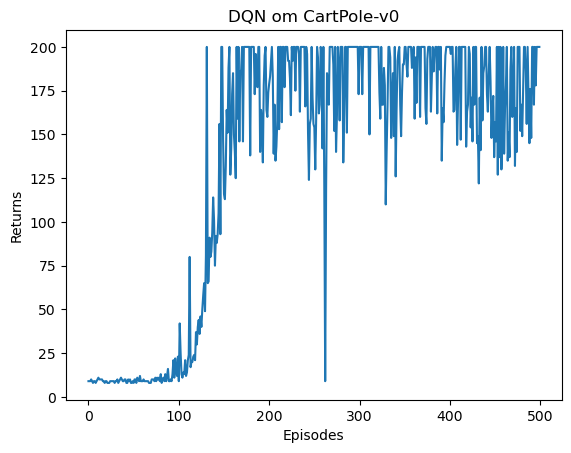

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN om {}'.format(env_name))
plt.show()

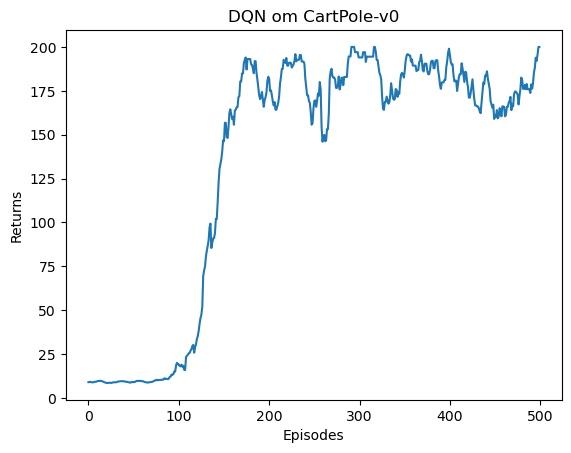

In [6]:
mv_return = rl_utils.moving_average(return_list, 9)
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, mv_return)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("DQN om {}".format(env_name))
plt.show()